In [2]:
import pandas as pd
import numpy as np
import sys, os, json, re

import pathlib
base_path = pathlib.Path().resolve().parents[1]
PROJECT_ROOT = pathlib.Path("../").resolve()
sys.path.insert(0, str(PROJECT_ROOT))
import paths

from pybads import BADS
import pickle as pkl
import matplotlib.pyplot as plt
import seaborn as sns
from math_analysis.potencial import get_expressions
from helpers.sim_helpers_fit import simulate_path, make_drift
from helpers.sim_helpers_fit_numba import run_trial_numba

from matplotlib.gridspec import GridSpec
from scipy import stats
from scipy.stats import pearsonr, spearmanr
from statannotations.Annotator import Annotator
from scipy.spatial import distance


# Imports and summary of data

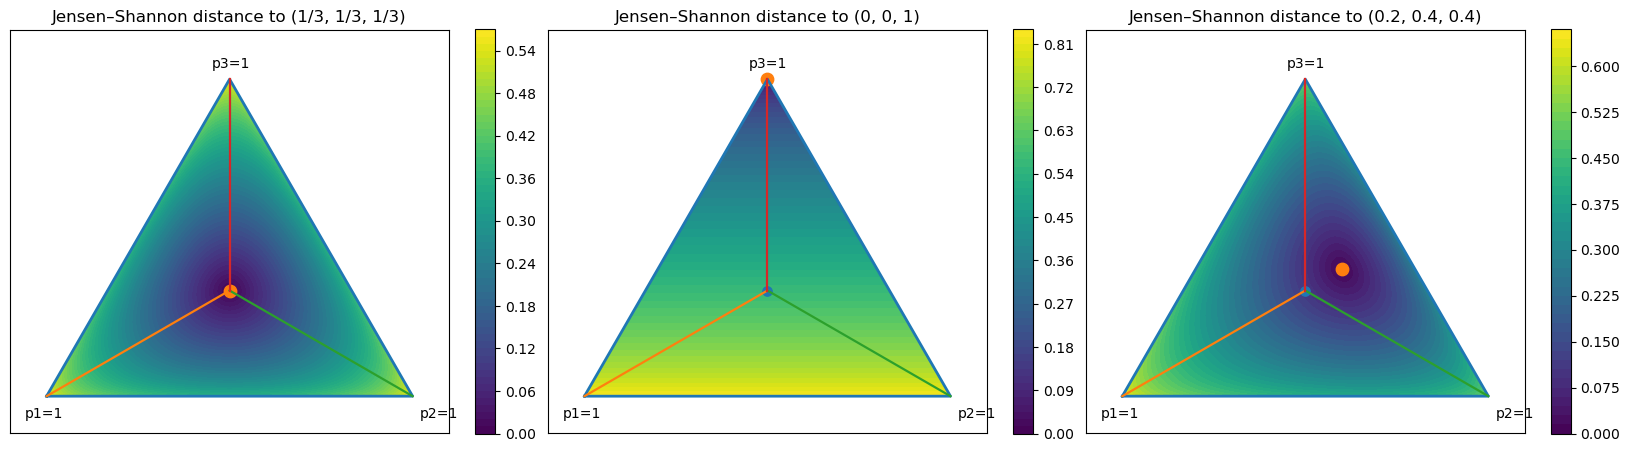

In [12]:
# Jensen–Shannon heatmaps on the 2-simplex (barycentric triangle)
# - Matplotlib: 3 subplots (one per reference) + barycenter→vertex lines
# - Plotly: interactive dropdown to choose reference point + rocket colorscale

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from scipy.spatial.distance import jensenshannon
from scipy.spatial import Delaunay
import plotly.graph_objects as go

# -----------------------------
# Geometry: barycentric -> 2D
# -----------------------------
V = np.array([
    [0.0, 0.0],                 # p1=1
    [1.0, 0.0],                 # p2=1
    [0.5, np.sqrt(3) / 2],      # p3=1 (equilateral)
], dtype=float)

def clamp_simplex(p, eps=0.0):
    p = np.asarray(p, float)
    p = np.clip(p, eps, None)
    s = p.sum(axis=-1, keepdims=True)
    s = np.where(s == 0, 1.0, s)
    return p / s

def bary_to_xy(p):
    """p: (...,3) with sum=1 -> (...,2)"""
    p = np.asarray(p, float)
    return p @ V

# -----------------------------
# Grid on the simplex
# -----------------------------
def simplex_grid(n=160):
    """Uniform lattice on simplex p1+p2+p3=1 with step 1/n."""
    pts = []
    for i in range(n + 1):
        p1 = i / n
        for j in range(n + 1 - i):
            p2 = j / n
            p3 = 1.0 - p1 - p2
            pts.append([p1, p2, p3])
    P = clamp_simplex(np.array(pts, float))
    XY = bary_to_xy(P)
    return P, XY

# -----------------------------
# Rocket colorscale
# -----------------------------
def rocket_colorscale(n=256):
    """
    Plotly colorscale named "rocket" (Seaborn).
    Tries seaborn; falls back to a baked palette if seaborn isn't installed.
    Returns a Plotly colorscale list: [[t,"rgb(r,g,b)"],...]
    """
    try:
        import seaborn as sns
        pal = sns.color_palette("rocket", n_colors=n)
        rgb = [(int(255*r), int(255*g), int(255*b)) for r, g, b in pal]
    except Exception:
        # Fallback: a small rocket-like ramp (interpolated to n)
        base = np.array([
            [  5,  7, 23],
            [ 25, 16, 66],
            [ 50, 21, 99],
            [ 78, 25, 115],
            [110, 28, 120],
            [142, 37, 111],
            [173, 58,  93],
            [202, 86,  70],
            [226, 124,  53],
            [242, 169,  66],
            [250, 214, 110],
        ], dtype=float)
        t0 = np.linspace(0, 1, len(base))
        t = np.linspace(0, 1, n)
        rgb = np.vstack([np.interp(t, t0, base[:, c]) for c in range(3)]).T
        rgb = [(int(r), int(g), int(b)) for r, g, b in rgb]

    return [[i/(n-1), f"rgb({r},{g},{b})"] for i, (r, g, b) in enumerate(rgb)]

# -----------------------------
# Distances
# -----------------------------
def js_distance_field(P, ref):
    ref = clamp_simplex(ref)
    d = np.array([jensenshannon(p, ref) for p in P], dtype=float)
    # Guard against rare NaNs (numerical corner cases)
    if np.any(~np.isfinite(d)):
        finite = d[np.isfinite(d)]
        fill = finite.max() if finite.size else 0.0
        d = np.nan_to_num(d, nan=fill, posinf=fill, neginf=fill)
    return d

# -----------------------------
# Matplotlib figure
# -----------------------------
def plot_matplotlib(P, XY, refs, titles):
    x, y = XY[:, 0], XY[:, 1]
    tri = mtri.Triangulation(x, y)

    border = bary_to_xy(np.array([[1,0,0],[0,1,0],[0,0,1],[1,0,0]], float))
    bary = np.array([1/3, 1/3, 1/3], float)
    bary_xy = bary_to_xy(bary)

    fig, axes = plt.subplots(1, len(refs), figsize=(5.4*len(refs), 5.2), constrained_layout=True)

    if len(refs) == 1:
        axes = [axes]

    for ax, r, title in zip(axes, refs, titles):
        d = js_distance_field(P, r)
        tcf = ax.tricontourf(tri, d, levels=60)
        fig.colorbar(tcf, ax=ax, fraction=0.046, pad=0.04)

        # triangle border
        ax.plot(border[:, 0], border[:, 1], linewidth=2)

        # barycenter -> vertices lines
        ax.plot([bary_xy[0], V[0,0]], [bary_xy[1], V[0,1]], linewidth=1.6)
        ax.plot([bary_xy[0], V[1,0]], [bary_xy[1], V[1,1]], linewidth=1.6)
        ax.plot([bary_xy[0], V[2,0]], [bary_xy[1], V[2,1]], linewidth=1.6)

        # mark barycenter and reference point
        ax.scatter([bary_xy[0]], [bary_xy[1]], s=45, marker="o")
        rxy = bary_to_xy(np.asarray(r).reshape(1,3))[0]
        ax.scatter([rxy[0]], [rxy[1]], s=80, marker="o")

        # labels
        ax.text(V[0,0]-0.06, V[0,1]-0.06, "p1=1")
        ax.text(V[1,0]+0.02, V[1,1]-0.06, "p2=1")
        ax.text(V[2,0]-0.05, V[2,1]+0.03, "p3=1")

        ax.set_title(title)
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlim(-0.1, 1.1); ax.set_ylim(-0.1, 1)
        ax.set_xticks([]); ax.set_yticks([])

    plt.show()

# -----------------------------
# Run everything
# -----------------------------

P, XY = simplex_grid(n=160)

refs = [
    [1/3, 1/3, 1/3],
    [0.0, 0.0, 1.0],
    [0.2, 0.4, 0.4],
]
refs = [clamp_simplex(r) for r in refs]

titles = [
    "to (1/3, 1/3, 1/3)",
    "to (0, 0, 1)",
    "to (0.2, 0.4, 0.4)",
]

# Matplotlib: 3 panels
plot_matplotlib(P, XY, refs, [f"Jensen–Shannon distance {t}" for t in titles])


In [27]:
import numpy as np
import plotly.graph_objects as go
from scipy.spatial.distance import jensenshannon

# -----------------------------
# Geometry: barycentric -> 2D (equilateral)
# -----------------------------
V = np.array([
    [0.0, 0.0],                 # p1=1
    [1.0, 0.0],                 # p2=1
    [0.5, np.sqrt(3) / 2],      # p3=1
], dtype=float)

def clamp_simplex(p, eps=0.0):
    p = np.asarray(p, float)
    p = np.clip(p, eps, None)
    s = p.sum(axis=-1, keepdims=True)
    s = np.where(s == 0, 1.0, s)
    return p / s

def bary_to_xy(p):
    p = np.asarray(p, float)
    return p @ V

# -----------------------------
# Simplex grid
# -----------------------------
def simplex_grid(n=180):
    pts = []
    for i in range(n + 1):
        p1 = i / n
        for j in range(n + 1 - i):
            p2 = j / n
            p3 = 1.0 - p1 - p2
            pts.append([p1, p2, p3])
    P = clamp_simplex(np.array(pts, float))
    XY = bary_to_xy(P)
    return P, XY

# -----------------------------
# Rocket colorscale (Plotly)
# -----------------------------
def rocket_colorscale(n=256):
    """
    Seaborn 'rocket' colorscale for Plotly.
    Tries seaborn; if not installed, falls back to a rocket-like ramp.
    """
    try:
        import seaborn as sns
        pal = sns.color_palette("rocket", n_colors=n)
        rgb = [(int(255*r), int(255*g), int(255*b)) for r, g, b in pal]
    except Exception:
        base = np.array([
            [  5,  7, 23],
            [ 25, 16, 66],
            [ 50, 21, 99],
            [ 78, 25,115],
            [110, 28,120],
            [142, 37,111],
            [173, 58, 93],
            [202, 86, 70],
            [226,124, 53],
            [242,169, 66],
            [250,214,110],
        ], dtype=float)
        t0 = np.linspace(0, 1, len(base))
        t = np.linspace(0, 1, n)
        rgb = np.vstack([np.interp(t, t0, base[:, c]) for c in range(3)]).T
        rgb = [(int(r), int(g), int(b)) for r, g, b in rgb]

    return [[i/(n-1), f"rgb({r},{g},{b})"] for i, (r, g, b) in enumerate(rgb)]

# -----------------------------
# JS distance field
# -----------------------------
def js_distance_field(P, ref):
    ref = clamp_simplex(ref)
    d = np.array([jensenshannon(p, ref) for p in P], dtype=float)
    if np.any(~np.isfinite(d)):
        finite = d[np.isfinite(d)]
        fill = finite.max() if finite.size else 0.0
        d = np.nan_to_num(d, nan=fill, posinf=fill, neginf=fill)
    return d

# -----------------------------
# Interactive 2D Plotly: click to set reference
# (Works in Jupyter / notebooks / VSCode interactive; uses FigureWidget callbacks)
# -----------------------------
P, XY = simplex_grid(n=250)
x, y = XY[:, 0], XY[:, 1]

# initial reference: barycenter
ref_idx = int(np.argmin((x - 0.5)**2 + (y - (np.sqrt(3)/6))**2))
ref = P[ref_idx]
d0 = js_distance_field(P, ref)

rocket = rocket_colorscale(256)

# Triangle border + barycenter→vertex lines
border = bary_to_xy(np.array([[1,0,0],[0,1,0],[0,0,1],[1,0,0]], float))
bary = np.array([1/3, 1/3, 1/3], float)
bary_xy = bary_to_xy(bary)

# Create FigureWidget so we can attach on_click
fig = go.FigureWidget()

# "Heatmap" as dense colored points (2D, fast with Scattergl)
heat = go.Scattergl(
    x=x, y=y,
    mode="markers",
    marker=dict(
        size=4,          # adjust
        opacity=1.0,
        color=d0,
        colorscale=rocket,
        colorbar=dict(title="JS dist"),
    ),
    hovertemplate="p1=%{customdata[0]:.3f}<br>p2=%{customdata[1]:.3f}<br>p3=%{customdata[2]:.3f}<br>JS=%{marker.color:.4f}<extra></extra>",
    customdata=P,
    name="JS heatmap",
)
fig.add_trace(heat)

# Border
fig.add_trace(go.Scatter(
    x=border[:,0], y=border[:,1],
    mode="lines",
    line=dict(width=3),
    name="simplex border",
    hoverinfo="skip"
))

# Barycenter→vertices
# Barycenter → vertices (BLANCAS y ENCIMA, WebGL)
for vv in V:
    fig.add_trace(go.Scattergl(
        x=[bary_xy[0], vv[0]],
        y=[bary_xy[1], vv[1]],
        mode="lines",
        line=dict(
            width=4,
            color="white"   # 🤍 blancas
        ),
        showlegend=False,
        hoverinfo="skip"
    ))

# Mark barycenter
fig.add_trace(go.Scatter(
    x=[bary_xy[0]], y=[bary_xy[1]],
    mode="markers+text",
    marker=dict(size=10),
    text=["barycenter"],
    textposition="top center",
    name="barycenter",
    hoverinfo="skip"
))

# Mark current reference point (updates on click)
# Mark current reference point (updates on click)  ✅ visible encima
# Mark current reference point (updates on click)  ✅ WebGL, encima del heatmap
ref_xy = bary_to_xy(ref.reshape(1,3))[0]
ref_marker = go.Scattergl(
    x=[ref_xy[0]], y=[ref_xy[1]],
    mode="markers",
    marker=dict(
        size=14,
        symbol="circle",
        color="orange",
        opacity=1.0,
        line=dict(color="black", width=3),
    ),
    text=["ref"],
    textposition="top center",
    name="reference",
    hoverinfo="skip"
)
fig.add_trace(ref_marker)

# Vertex labels
fig.add_annotation(x=V[0,0]-0.05, y=V[0,1]-0.05, text=r'(1,0,0)', showarrow=False)
fig.add_annotation(x=V[1,0]+0.05, y=V[1,1]-0.05, text=r'(0,1,0)', showarrow=False)
fig.add_annotation(x=V[2,0],      y=V[2,1]+0.05, text=r'(0,0,1)', showarrow=False)

fig.update_layout(
    title="Click inside the triangle to choose the reference point (JS distance)",
    xaxis=dict(visible=False),
    yaxis=dict(visible=False, scaleanchor="x", scaleratio=1),
    margin=dict(l=10, r=10, t=60, b=10),
)

# --- Click callback: set ref = clicked grid point (nearest), recompute JS, update colors ---
def on_click(trace, points, selector):
    if not points.point_inds:
        return
    idx = points.point_inds[0]
    new_ref = P[idx]
    new_d = js_distance_field(P, new_ref)
    new_ref_xy = XY[idx]

    with fig.batch_update():
        fig.data[0].marker.color = new_d          # heat trace
        fig.data[-1].x = [new_ref_xy[0]]          # ref marker (last trace)
        fig.data[-1].y = [new_ref_xy[1]]
        fig.layout.title = f"JS distance to ref = ({new_ref[0]:.3f}, {new_ref[1]:.3f}, {new_ref[2]:.3f})"

fig.data[0].on_click(on_click)

fig

FigureWidget({
    'data': [{'customdata': array([[0.00000000e+00, 0.00000000e+00, 1.00000000e+00],
                                   [0.00000000e+00, 4.00000000e-03, 9.96000000e-01],
                                   [0.00000000e+00, 8.00000000e-03, 9.92000000e-01],
                                   ...,
                                   [9.96000000e-01, 0.00000000e+00, 4.00000000e-03],
                                   [9.96000000e-01, 4.00000000e-03, 3.46944695e-18],
                                   [1.00000000e+00, 0.00000000e+00, 0.00000000e+00]]),
              'hovertemplate': ('p1=%{customdata[0]:.3f}<br>p2=' ... 'rker.color:.4f}<extra></extra>'),
              'marker': {'color': array([0.56250571, 0.55330224, 0.54646579, ..., 0.55577257, 0.55579399,
                                         0.5649622 ]),
                         'colorbar': {'title': {'text': 'JS dist'}},
                         'colorscale': [[0.0, 'rgb(2,4,25)'],
                                     